# 单音干扰仿真（Single-Tone Interference）

本 Notebook 演示如何：
- 根据干噪比（INR）生成单音干扰
- 合成热噪声与干扰信号
- 可视化时域波形、功率谱和语谱图

> 📚 理论参考：`docs/interference_models.md`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, spectrogram
from girk.interference.generators import single_tone_interference

In [2]:
# =============================================================================
# 1. 全局系统参数（用户可调）
# =============================================================================
fs = 21e6                # 采样率 (21 Msps)
duration = 0.01          # 信号时长 (10 ms)
freq_offset = 2.5e6      # 单音干扰频偏 (2.5 MHz from carrier)
inr_db = 30.0            # 干噪比 (Interference-to-Noise Ratio, in dB)

# =============================================================================

In [3]:
# =============================================================================
# 2. 噪声建模：热噪声功率归一化为 1
# =============================================================================
n_samples = int(fs * duration)
# 生成复高斯白噪声，功率 = 1 (即 E[|n|^2] = 1)
# np.random.seed(42)  # 保证结果可复现
noise = (np.random.randn(n_samples) + 1j * np.random.randn(n_samples)) / np.sqrt(2)

# 验证噪声功率
noise_power = np.mean(np.abs(noise)**2)
print(f"Thermal noise power: {noise_power:.3f} (target = 1.0)")

Thermal noise power: 1.002 (target = 1.0)


In [4]:
# =============================================================================
# 3. 干扰建模：根据 INR 计算干扰功率
#    INR (dB) = 10 * log10(P_interf / P_noise)  =>  P_interf = P_noise * 10^(INR/10)
# =============================================================================
inr_linear = 10**(inr_db / 10)   # 转换为线性值
interference_power = noise_power * inr_linear  # 干扰功率

print(f"INR = {inr_db} dB → Interference power = {interference_power:.1f}")

# 生成单音干扰
interference = single_tone_interference(
    fs=fs,
    freq_offset=freq_offset,
    duration=duration,
    power=interference_power,
    phase0=0.0
)

# 验证干扰功率
interference_est_power = np.mean(np.abs(interference)**2)
print(f"Actual interference power: {interference_est_power:.1f}")

INR = 30.0 dB → Interference power = 1001.7
Actual interference power: 1001.7


In [5]:
# =============================================================================
# 4. 信号合成：interference + 热噪声
# =============================================================================
received_signal = interference + noise

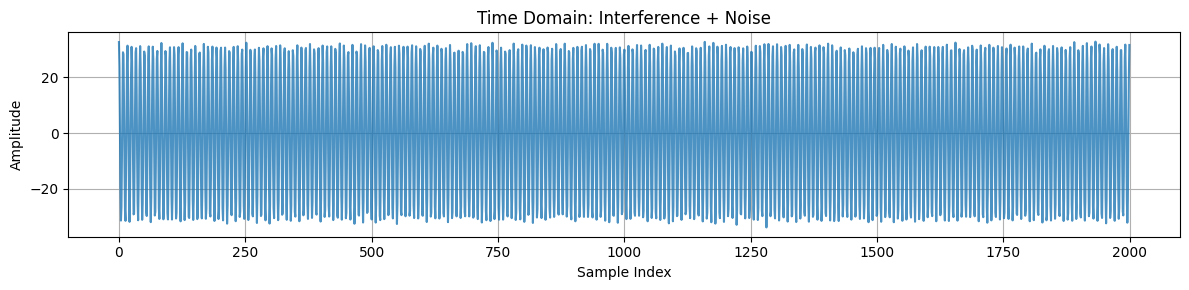

In [6]:
# =============================================================================
# 5. 可视化
# =============================================================================

# --- 时域波形（实部） ---
plt.figure(figsize=(12, 3))
plt.plot(np.real(received_signal[:2000]), label='Received Signal (Real)', alpha=0.8)
plt.title('Time Domain: Interference + Noise')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

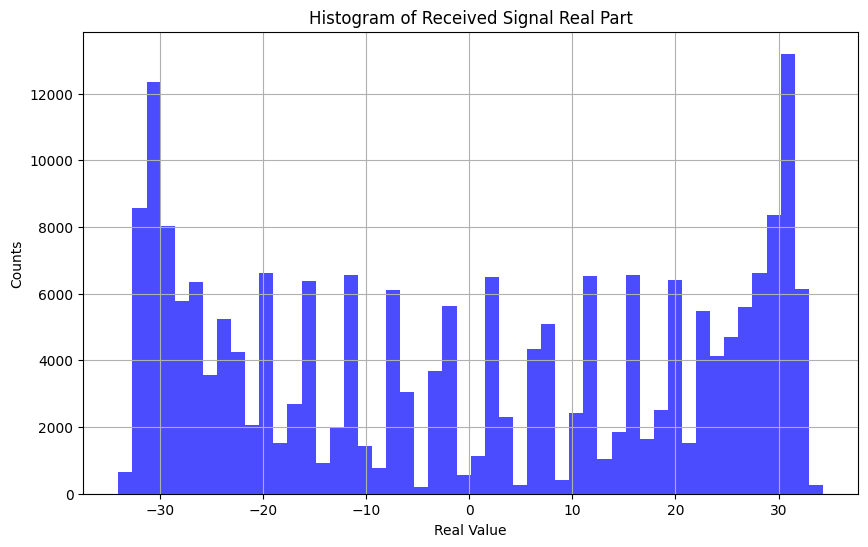

In [7]:
# --- 直方图（Histrogram）---
plt.figure(figsize=(10, 6))
plt.hist(np.real(received_signal), bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Received Signal Real Part')
plt.xlabel('Real Value')
plt.ylabel('Counts')
plt.grid(True)
plt.show()

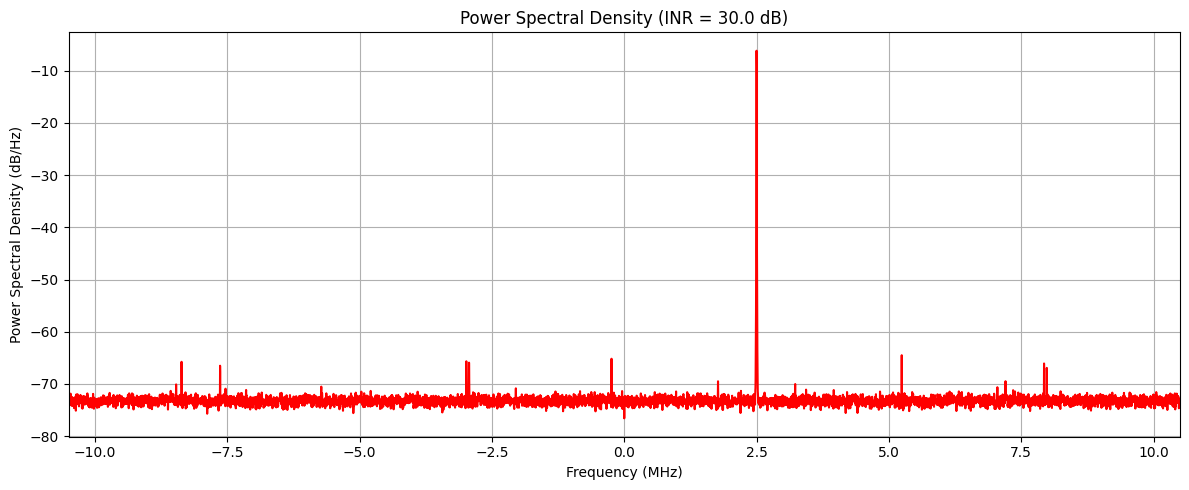

In [8]:
# --- 功率谱密度（PSD）---
from scipy.signal import welch

def plot_psd(signal, fs, label, color='C0'):
    f, psd = welch(signal, fs=fs, nperseg=8192, return_onesided=False)
    # 转换为 dB-Hz（相对于 1 Hz 带宽）
    psd_db = 10 * np.log10(psd)
    # 频率搬移到 [-fs/2, fs/2]
    f_shifted = np.fft.fftshift(f)
    psd_db_shifted = np.fft.fftshift(psd_db)
    plt.plot(f_shifted / 1e6, psd_db_shifted, color=color, label=label)

plt.figure(figsize=(12, 5))
plot_psd(received_signal, fs, 'Received Signal', 'red')

plt.title(f'Power Spectral Density (INR = {inr_db} dB)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power Spectral Density (dB/Hz)')
plt.xlim(-fs/2/1e6, fs/2/1e6)
plt.grid(True)
plt.tight_layout()
plt.show()

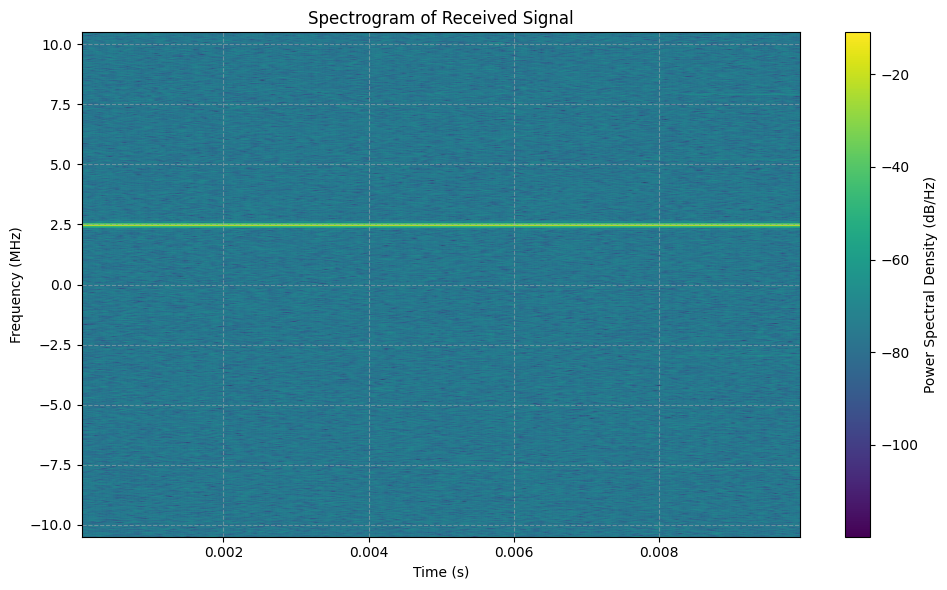

In [9]:
# --- 时频二维图（Spectrogram）---
f, t, Sxx = spectrogram(
    received_signal,           # 
    fs=fs,
    nperseg=2048,          # 窗长（建议 2^N）
    noverlap=1024,         # 重叠（可选）
    return_onesided=False, # 必须！返回双边谱
    scaling='density'      # 功率谱密度（单位：V²/Hz）
)

# 将频谱搬移到 [-fs/2, fs/2] 并转换为 dB
Sxx_db = 10 * np.log10(np.abs(Sxx) + 1e-12)  # 加小量防 log(0)
f_shifted = np.fft.fftshift(f)
Sxx_db_shifted = np.fft.fftshift(Sxx_db, axes=0)

# 绘图
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f_shifted / 1e6, Sxx_db_shifted, shading='gouraud', cmap='viridis')
plt.ylabel('Frequency (MHz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram of Received Signal')
plt.colorbar(label='Power Spectral Density (dB/Hz)')
plt.ylim(-fs/2/1e6, fs/2/1e6)  # 显示完整基带频谱
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 📌 结论

- 单音干扰在频域表现为**尖锐谱线**，在时频图中为**水平直线**
- 当 INR > 20 dB 时，干扰完全淹没噪声底
- 此模型可用于测试抗干扰算法（如 notch filter、自适应调零）

> 下一步：尝试 `examples/02_narrowband_interference.ipynb`